Let's load our saved data first, fresh, to confirm Notebook 2 is self-contained:

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rfm = pd.read_csv(r'../Data/rfm.csv')
feature_scaled_df = pd.read_csv(r'../Data/feature_scaled_df.csv', index_col='Customer ID')

Let's verify everything is intact

In [3]:
print(rfm.shape)
print(feature_scaled_df.shape)

(5878, 6)
(5878, 3)


Okay, everything is as it is.

## Principal component Analysis (PCA)

In [4]:
from sklearn.decomposition import PCA

In [5]:
pca = PCA(n_components=2)

In [6]:
pca_result = pca.fit_transform(feature_scaled_df)

Let's check how much veriance our model PCA components capture:

In [7]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.74725232 0.20325631]
0.9505086343884523


`[0.74725232, 0.20325631]` — PC1 captures 74.7% of the variance, PC2 captures 20.3%. Two numbers because we asked for `n_components=2`.

`.sum()` — just adding those two numbers together: `0.747 + 0.203 = 0.9505`. This tells us the combined amount of information your 2D projection retains out of the original 3 features. 95.05% retained means only ~5% of the original variance was "lost" by compressing from 3 dimensions down to 2,meaning almost nothing meaningful is lost.

**Next:** Let's visualize it:

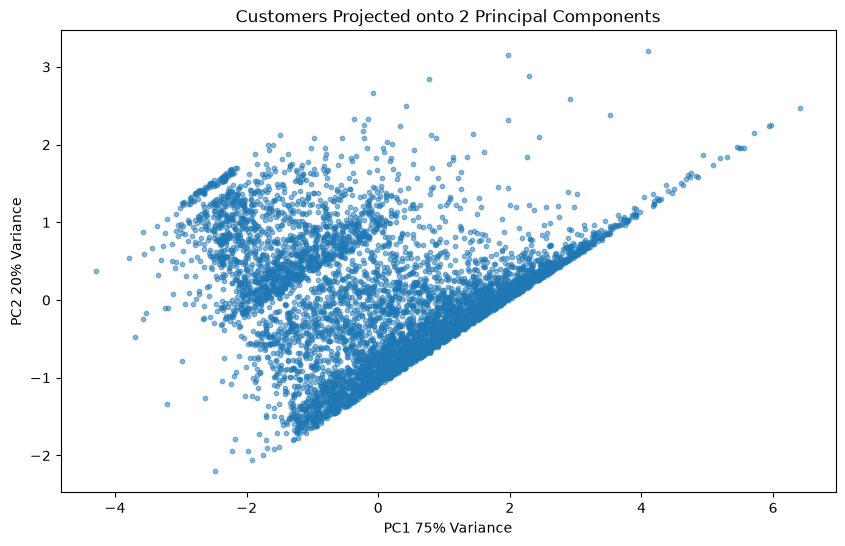

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, s=10)
plt.xlabel('PC1 75% Variance')
plt.ylabel('PC2 20% Variance')
plt.title('Customers Projected onto 2 Principal Components')
plt.show()

**What the shape tells us:**

* No clean, separated blobs. This is one continuous, dense cloud that thins out as it spreads — not 3-4 visually distinct islands with empty space  between them. That's an honest, important finding: our customer base doesn't naturally split into obviously separate groups. Customer behavior here is more of a spectrum (gradually more engaged → gradually less engaged) than distinct categories.

* The triangular/fan shape, densest near the bottom-left, thinning as it goes up and right. Most customers cluster tightly in the lower-left (low PC1, low-to-mid PC2) — this is our "typical" customer mass. As we move up and to the right, points get sparser — these are increasingly extreme/unusual customers.

* The scattered outlier points far to the right (PC1 ≈ 4-6.5) and the ones near the top (PC2 ≈ 2.5-3.2). These are very likely our wholesale-pattern customers from earlier — remember our CustomerID 16446, 18102, 14646? High Monetary/Frequency pulls them far from the main cloud along these axes. we're seeing the exact outlier behavior we investigated earlier, now visually confirmed.

**Why this matters for what comes next:**

Given there's no obvious visual separation into clean groups, don't expect K-Means to find some clean, obvious answer that jumps out at us either. The **elbow method** and **silhouette score** will likely show a soft signal, not a dramatic one. 

This is also exactly the kind of shape where DBSCAN's behavior will look meaningfully different from K-Means: DBSCAN, being density-based, may treat that dense lower-left mass as one or two clusters and correctly flag the sparse scattered points on the right/top as noise — while K-Means, forced to partition everything into exactly k groups regardless of density, will carve arbitrary boundaries through this continuous cloud, potentially even splitting the dense mass into artificial sub-groups just to satisfy k.

## K-Means clustering

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

In [10]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(feature_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(feature_scaled_df, labels))

**Note:** *`n_init=10` means, K-Means is run 10 separate times with different random starting centroids, and sklearn keeps the best result (lowest inertia). This guards against a single unlucky random start giving us a misleadingly bad result.*

Now let's plot both — elbow curve and silhouette curve, side by side, so we can compare where they agree or disagree.

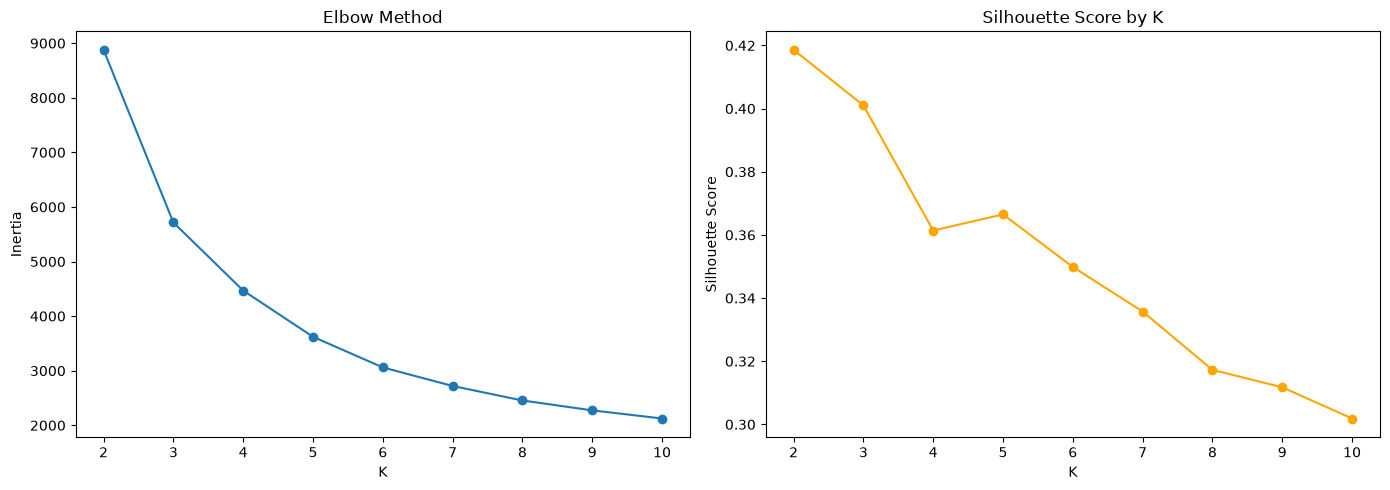

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, marker='o')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')

plt.tight_layout()
plt.show()

**Elbow plot:**\
The sharpest drop is from k=2→3 (8900→5700), and a second, smaller bend around k=3→4 (5700 → 4450). After k=4, the curve flattens into a long, gentle decline with no more real bends, each additional cluster buys us less and less.

**Silhouette plot:**\
Highest score is at k=2 (0.418), drops at k=3 (0.401), dips further at k=4 (0.361), then a small local bump at k=5 (0.367), before declining steadily onward. k=2 is mathematically the "best" by this metric, but k=2 is also almost always too coarse to be useful for customer segmentation, splitting our entire base into just 2 groups rarely gives a business anything actionable ("high value" vs "everyone else" is barely a segmentation).

**Where they agree, which is what actually matters:**\
Both plots show k=2 and k=3 as strong performers, with k=4 as the point where the elbow visibly flattens and silhouette takes its biggest drop after k=3. That convergence — elbow bending around 3-4, silhouette favoring 2-3 with a real dip starting at 4 — points to k=3 or k=4 as our defensible range, not k=2 (too coarse to be useful) and not the higher values (silhouette keeps declining, offering no benefit).

**Final decision**\
Let's go with **`k=4`** beacuse silhouette score technically peaks at `k=2`, but this offers limited business value. `k=4` is being selected as the point where the elbow curve flattens and silhouette score remains reasonable (0.361), balancing statistical fit against interpretability, a common tradeoff in real-world clustering.

In [33]:
kmeans_final = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(feature_scaled_df)

Let's check how many customers landed in each of the 4 clusters:

In [34]:
np.unique(kmeans_labels, return_counts=True)

(array([0, 1, 2, 3], dtype=int32), array([1638, 1384, 1891,  965]))

this is a genuinely healthy split
* Cluster 0: 1,638 customers
* Cluster 1: 1,384 customers
* Cluster 2: 1,891 customers
* Cluster 3: 965 customers

No cluster is empty, none is a tiny handful (like 5 or 20 customers), and none dominates by absorbing 90%+ of the data. The largest (1,891) is only about 2x the smallest (965), which is a reasonably balanced split across all four groups out of ~5,878 total customers.

**Next:** Let's plot the clusters on our existing PCA scatter:

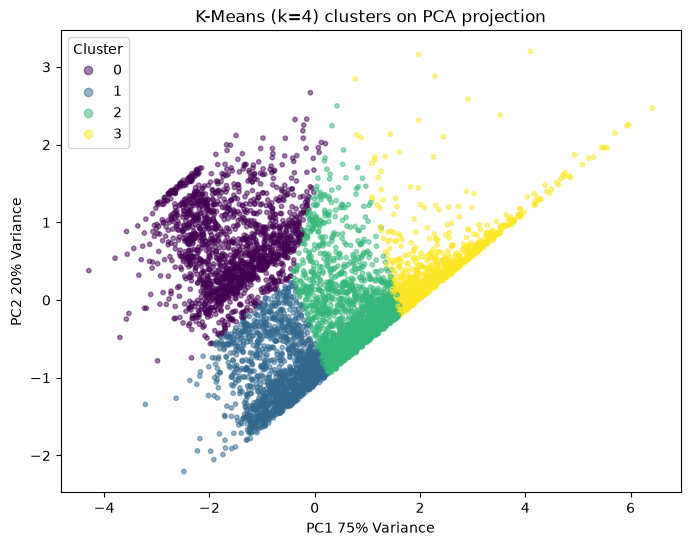

In [38]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.5, s=10)
plt.xlabel('PC1 75% Variance')
plt.ylabel('PC2 20% Variance')
plt.title('K-Means (k=4) clusters on PCA projection')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()


**NOTE:**\
*`c=kmeans_labels` - colors each point according to which cluster it was assigned to, instead of one flat color*\
*`cmap='viridis'` - a colormap that gives each of the 4 clusters a visually distinct color*\
*`scatter.legend_elements()` - automatically builds a legend mapping colors to cluster numbers, so we don't have to hardcode it*

K-Means separates clusters using straight-line boundaries (visible where cluster colors meet), but because the underlying PCA-projected data forms an irregular,\
fan-shaped cloud rather than distinct round groups, the resulting cluster regions appear as irregular wedges rather than clean, compact shapes.